# JPEG Decode Python Sample
## Single file, data

In [1]:
import torch
import pyRocJpegDecode.decoder as jdec
import numpy as np
from PIL import Image
from IPython.display import display
import cv2

In [2]:
def display_tensor(tensor, width, height):
    arr = tensor.cpu().numpy()
    yuv_nv12 = arr.reshape((height * 3) // 2, width)
    bgr = cv2.cvtColor(yuv_nv12, cv2.COLOR_YUV2BGR_NV12)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)
    new_size = (img.width // 8, img.height // 8)
    img_resized = img.resize(new_size, Image.LANCZOS)
    display(img_resized)

Using the rocPyJpeg **`read`** API to read and decode from a file path:

In [3]:
device_id = 0
backend = 0
img_full_path = "/opt/rocm/share/rocjpeg/images/mug_420.jpg"

decoder = jdec.decoder(device_id, backend)

cs = jdec.DecodeSource(img_full_path).cs()
width = cs.width
height = cs.height

image1 = decoder.read(img_full_path)

Using GPU device 0: Radeon RX 7900 XT[gfx1100] on PCI bus 03:00.0
Input file name: "/opt/rocm/share/rocjpeg/images/mug_420.jpg"
Input image resolution: 3840x2160
Chroma subsampling STR: YUV 4:2:0
Chroma subsampling INT: 3
Input file name: "/opt/rocm/share/rocjpeg/images/mug_420.jpg"
Input image resolution: 3840x2160
Chroma subsampling STR: YUV 4:2:0
Chroma subsampling INT: 3
Cleaning up single image.


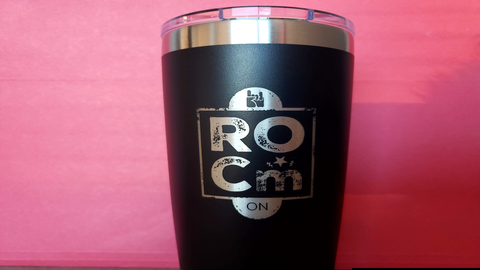

In [4]:
tensor1 = torch.from_numpy(image1.to_numpy_8bits())
display_tensor(tensor1, width, height)

Or the rocPyJpeg **`decode`** API to decode from an in-memory encoded stream: 

In [5]:
try:
    with open(img_full_path, 'rb') as in_file:
        data = in_file.read()
        if not data:
            raise ValueError("File is empty.")
except Exception as e:
    print(f"Failed to read file: {e}")

image2 = decoder.decode(data)

Input image resolution: 3840x2160
Chroma subsampling STR: YUV 4:2:0
Chroma subsampling INT: 3
Cleaning up single image code_stream.
Cleaning up single image.


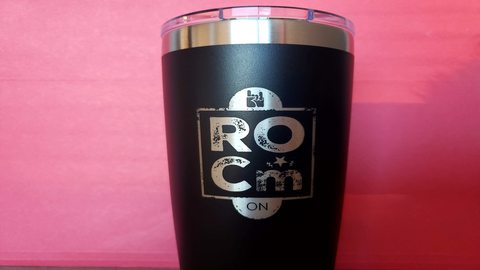

In [6]:
tensor2 = torch.from_numpy(image2.to_numpy_8bits())
display_tensor(tensor2, width, height)